<a href="https://colab.research.google.com/github/rakshitpeshne/ml_project/blob/main/mlproject_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:

!pip install -q pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" Libraries imported")

 Libraries imported


In [2]:

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
print(f" Data loaded: {df.shape}")
df.head()

 Data loaded: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:

le_sex = LabelEncoder()
le_smoker = LabelEncoder()
le_region = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])           # female:0, male:1
df['smoker'] = le_smoker.fit_transform(df['smoker'])   # no:0, yes:1
df['region'] = le_region.fit_transform(df['region'])   # 0,1,2,3

# Split features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(" Data ready for training")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

 Data ready for training
Training samples: 1070
Test samples: 268


In [13]:

models = {
    '1. Linear Regression': LinearRegression(),
    '2. Ridge Regression': Ridge(alpha=1.0),
    '3. Lasso Regression': Lasso(alpha=1.0),
    '4. Decision Tree': DecisionTreeRegressor(random_state=42),
    '5. Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    '6. Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    '7. SVM': SVR(kernel='rbf'),
    '8. KNN': KNeighborsRegressor(n_neighbors=5)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store results
    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE': f"${mae:,.0f}",
        'RMSE': f"${rmse:,.0f}"
    })

    print(f"{name} -> R2: {r2:.4f}, MAE: ${mae:,.0f}")

1. Linear Regression -> R2: 0.7833, MAE: $4,187
2. Ridge Regression -> R2: 0.7833, MAE: $4,188
3. Lasso Regression -> R2: 0.7833, MAE: $4,187
4. Decision Tree -> R2: 0.6950, MAE: $3,070
5. Random Forest -> R2: 0.8654, MAE: $2,518
6. Gradient Boosting -> R2: 0.8781, MAE: $2,447
7. SVM -> R2: -0.0682, MAE: $8,599
8. KNN -> R2: 0.8345, MAE: $3,046


In [14]:
# Create results table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 Score', ascending=False)
print("\n" + "="*60)
print(" MODEL PERFORMANCE (Best to Worst)")
print("="*60)
print(results_df.to_string(index=False))

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2 Score']
print(f"\n Best Model: {best_model_name} with R2 Score = {best_r2}")


 MODEL PERFORMANCE (Best to Worst)
               Model  R2 Score    MAE    RMSE
6. Gradient Boosting    0.8781 $2,447  $4,351
    5. Random Forest    0.8654 $2,518  $4,572
              8. KNN    0.8345 $3,046  $5,069
1. Linear Regression    0.7833 $4,187  $5,800
 2. Ridge Regression    0.7833 $4,188  $5,800
 3. Lasso Regression    0.7833 $4,187  $5,800
    4. Decision Tree    0.6950 $3,070  $6,881
              7. SVM   -0.0682 $8,599 $12,878

 Best Model: 6. Gradient Boosting with R2 Score = 0.8781


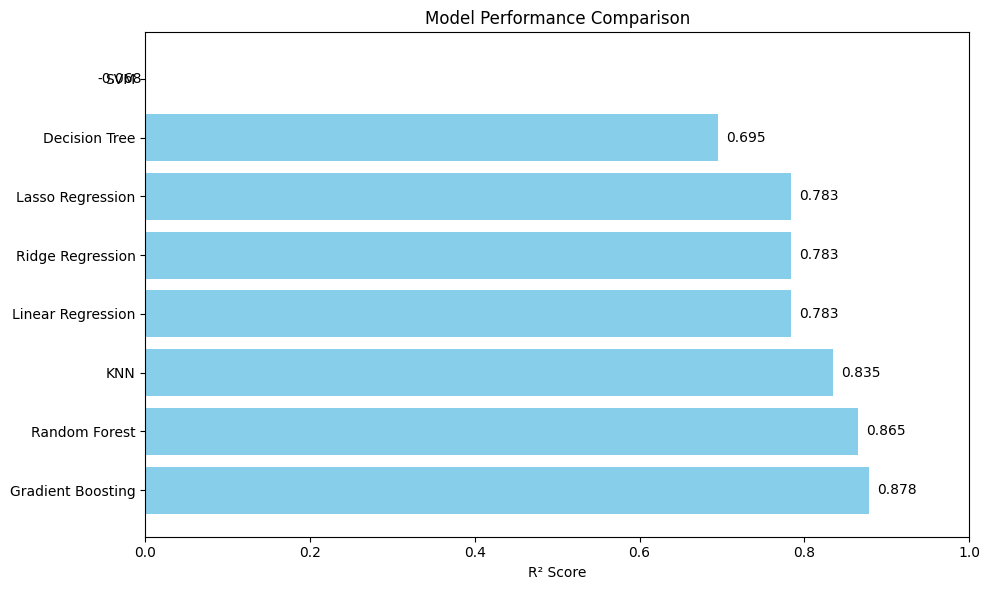

In [15]:
# Plot comparison
plt.figure(figsize=(10, 6))
models_short = [m.split('. ')[1] for m in results_df['Model']]
r2_scores = [float(s) for s in results_df['R2 Score']]

plt.barh(models_short, r2_scores, color='skyblue')
plt.xlabel('R² Score')
plt.title('Model Performance Comparison')
plt.xlim(0, 1)

# Add values on bars
for i, v in enumerate(r2_scores):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()